# 📱 Smartphone Recommendation บน Neo4j Online (Aura)

```
(PhoneUser) ──LIKES────► (Smartphone) ──MADE_BY──► (Brand)
   ผู้ใช้        ชอบ         มือถือ        ผลิตโดย      ยี่ห้อ
```

| Relationship | ระหว่าง | ความหมาย |
|---|---|---|
| `LIKES` | PhoneUser → Smartphone | ผู้ใช้ชอบมือถือรุ่นนี้ |
| `MADE_BY` | Smartphone → Brand | มือถือรุ่นนี้เป็นของยี่ห้อไหน |

**แนวคิดแนะนำ**
1. คนที่ชอบมือถือเหมือนเรา → ชอบรุ่นอะไรอีก → แนะนำรุ่นนั้น
2. ถ้าไม่มีใครชอบเหมือนเรา → แนะนำรุ่นอื่นใน **ยี่ห้อเดียวกัน**

ตัวอย่างสถานการณ์ มีผู้ใช้ 5 คน```Narin   FahPloy    KritBank```และมีมือถือ 8 รุ่น จาก 4 ยี่ห้อ```Apple:   iPhone 16, iPhone 16 ProSamsung: Galaxy S25, Galaxy S25 UltraXiaomi:  Xiaomi 15, Xiaomi 15 UltraGoogle:  Pixel 9, Pixel 9 Pro```สมมติข้อมูลความชอบ (LIKES) รวม 11 เส้นเชื่อม```Narin → iPhone 16, Galaxy S25Ploy  → Galaxy S25, Xiaomi 15Bank  → iPhone 16, Galaxy S25, Xiaomi 15Fah   → iPhone 16 Pro, Pixel 9 ProKrit  → Pixel 9 Pro, Xiaomi 15```จะเห็นว่าเริ่มมีกลุ่มก้อนชัดขึ้น เช่น กลุ่มที่ชอบ iPhone/Galaxy (Narin, Bank)และกลุ่มที่ชอบ Pixel (Fah, Krit)

```เราจะสังเกตได้ว่าNarin ชอบ iPhone 16 และ Galaxy S25คนที่ชอบมือถือซ้ำกับ Narin มีคนเดียวคือ Bankและ Bank ยังชอบ Xiaomi 15 ด้วยแต่ Narin ยังไม่มี Xiaomi 15ระบบจึงแนะนำ Xiaomi 15 ให้ Narinยิ่งผู้ใช้เยอะ คะแนนยิ่งแยกอันดับได้ชัดขึ้นเพราะมือถือรุ่นเดียวกันถูกเดินไปถึงหลายเส้นทาง(เช่น Xiaomi 15 ถูกเดินถึงผ่านทั้ง Bank และ Ploy จึงได้คะแนนสูงกว่า)```

การออกแบบ Graph```เราแบ่ง Node เป็น 3 ประเภท  (:PhoneUser {name})  (:Smartphone {name})  (:Brand {name})Relationship คือ  LIKES     (PhoneUser -> Smartphone)  MADE_BY   (Smartphone -> Brand)ดังนั้น  (PhoneUser)-[:LIKES]->(Smartphone)-[:MADE_BY]->(Brand)เช่น  (:PhoneUser {name:'Narin'})-[:LIKES]->(:Smartphone {name:'iPhone 16'})  (:Smartphone {name:'iPhone 16'})-[:MADE_BY]->(:Brand {name:'Apple'})```ใน Neo4j ความสัมพันธ์มีทิศทางเสมอ แต่ตอน Query เราเดินย้อนทิศได้ด้วย `<-[:LIKES]-` หรือ `<-[:MADE_BY]-`จึงไม่ต้องสร้างเส้นกลับเหมือน Undirected Graph

Step 1 — ติดตั้ง Neo4j driver

In [ ]:
!pip install -q neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.5/331.5 kB 7.3 MB/s eta 0:00:00


In [ ]:
import neo4j

print("Neo4j Python Driver Version:", neo4j.__version__)

Neo4j Python Driver Version: 6.3.1


Step 2 — เชื่อมต่อ Neo4j online server

In [ ]:
from getpass import getpass
from neo4j import GraphDatabase

URI = "neo4j+s://37b66f55.databases.neo4j.io"
USERNAME = "37b66f55"
PASSWORD = getpass("Password: ")

driver = GraphDatabase.driver(
    URI,
    auth=(USERNAME, PASSWORD)
)

driver.verify_connectivity()

print("Connected successfully")

Password: ··········
Connected successfully


Step 3 — หา home database แล้วเก็บชื่อไว้

In [ ]:
result = driver.execute_query(
    "SHOW HOME DATABASE"
)

for record in result.records:
    print(record.data())

{'name': '37b66f55', 'type': 'standard', 'aliases': [], 'access': 'read-write', 'address': 'p-mt-3b814dd7cab7-1-0176.production-orch-0068.neo4j.io:7687', 'role': 'primary', 'writer': True, 'requestedStatus': 'online', 'currentStatus': 'online', 'statusMessage': '', 'constituents': []}


In [ ]:
DATABASE = result.records[0]["name"]

print("Database =", DATABASE)

Database = 37b66f55


Step 4 — ล้างข้อมูลเก่า (รันซ้ำได้)

ลบเฉพาะ Label ของโปรเจกต์นี้ (`PhoneUser`, `Smartphone`, `Brand`) ไม่กระทบข้อมูลคนอื่น

In [ ]:
driver.execute_query(
    """
    MATCH (n)

    WHERE n:PhoneUser OR n:Smartphone OR n:Brand

    DETACH DELETE n
    """,
    database_=DATABASE
)

print("ล้างข้อมูลเก่าเรียบร้อย")

ล้างข้อมูลเก่าเรียบร้อย


Step 5 — สร้าง Constraint (กันชื่อซ้ำ)

In [ ]:
constraints = [
    "CREATE CONSTRAINT phoneuser_name_unique IF NOT EXISTS FOR (u:PhoneUser) REQUIRE u.name IS UNIQUE",
    "CREATE CONSTRAINT smartphone_name_unique IF NOT EXISTS FOR (p:Smartphone) REQUIRE p.name IS UNIQUE",
    "CREATE CONSTRAINT brand_name_unique IF NOT EXISTS FOR (b:Brand) REQUIRE b.name IS UNIQUE"
]

for q in constraints:
    driver.execute_query(q, database_=DATABASE)

print("สร้าง Constraint ทั้ง 3 ชนิดแล้ว")

สร้าง Constraint ทั้ง 3 ชนิดแล้ว


Step 6 — สร้าง Node ชนิดที่ 1: ผู้ใช้ (5 คน)

In [ ]:
users = ["Narin", "Ploy", "Bank", "Fah", "Krit"]

In [ ]:
result = driver.execute_query(
    """
    UNWIND $users AS name

    MERGE (u:PhoneUser {name: name})

    RETURN count(u) AS total
    """,

    users=users,
    database_=DATABASE
)

print("จำนวน PhoneUser =", result.records[0]["total"])

จำนวน PhoneUser = 5


Step 7 — สร้าง Node ชนิดที่ 2: มือถือ (8 รุ่น) และชนิดที่ 3: ยี่ห้อ (4 ยี่ห้อ ยี่ห้อละ 2 รุ่น)

เขียนเป็นคู่ `(รุ่น, ยี่ห้อ)` ชุดเดียว แล้วใช้ทั้งสร้าง Node มือถือ และสร้างความสัมพันธ์ `MADE_BY`

In [ ]:
phone_brand = [
    ("iPhone 16",        "Apple"),
    ("iPhone 16 Pro",    "Apple"),
    ("Galaxy S25",       "Samsung"),
    ("Galaxy S25 Ultra", "Samsung"),
    ("Xiaomi 15",        "Xiaomi"),
    ("Xiaomi 15 Ultra",  "Xiaomi"),
    ("Pixel 9",          "Google"),
    ("Pixel 9 Pro",      "Google")
]

phone_brand_data = [
    {"phone": p, "brand": b}
    for p, b in phone_brand
]

In [ ]:
driver.execute_query(
    """
    UNWIND $rows AS row

    MERGE (p:Smartphone {name: row.phone})
    MERGE (b:Brand {name: row.brand})

    """,

    rows=phone_brand_data,
    database_=DATABASE
)

print("สร้าง Smartphone และ Brand สำเร็จ")

สร้าง Smartphone และ Brand สำเร็จ


---
# ส่วนความสัมพันธ์ (มีแค่ 2 แบบ)

Step 8 — Relationship แบบที่ 1: `MADE_BY` (มือถือรุ่นนี้ของยี่ห้อไหน)

```
iPhone 16, iPhone 16 Pro          → Apple
Galaxy S25, Galaxy S25 Ultra      → Samsung
Xiaomi 15, Xiaomi 15 Ultra        → Xiaomi
Pixel 9, Pixel 9 Pro              → Google
```

In [ ]:
driver.execute_query(
    """
    UNWIND $rows AS row

    MATCH
        (p:Smartphone {name: row.phone}),
        (b:Brand {name: row.brand})

    MERGE
        (p)-[:MADE_BY]->(b)
    """,

    rows=phone_brand_data,
    database_=DATABASE
)

print("สร้าง MADE_BY สำเร็จ")

สร้าง MADE_BY สำเร็จ


Step 9 — Query: Samsung มีมือถือรุ่นอะไรบ้าง (เดินย้อนทิศด้วย `<-`)

In [ ]:
result = driver.execute_query(
    """
    MATCH (p:Smartphone)-[:MADE_BY]->(b:Brand {name: 'Samsung'})

    RETURN p.name AS phone

    ORDER BY phone
    """,
    database_=DATABASE
)

print([record["phone"] for record in result.records])

['Galaxy S25', 'Galaxy S25 Ultra']


Step 10 — Relationship แบบที่ 2: `LIKES` (ใครชอบรุ่นไหน)

```
Narin → iPhone 16, Galaxy S25
Ploy  → Galaxy S25, Xiaomi 15
Bank  → iPhone 16, Galaxy S25, Xiaomi 15
Fah   → iPhone 16 Pro, Pixel 9 Pro
Krit  → Pixel 9 Pro, Xiaomi 15
```
รวม 11 เส้น

In [ ]:
likes = [
    ("Narin", "iPhone 16"),
    ("Narin", "Galaxy S25"),

    ("Ploy", "Galaxy S25"),
    ("Ploy", "Xiaomi 15"),

    ("Bank", "iPhone 16"),
    ("Bank", "Galaxy S25"),
    ("Bank", "Xiaomi 15"),

    ("Fah", "iPhone 16 Pro"),
    ("Fah", "Pixel 9 Pro"),

    ("Krit", "Pixel 9 Pro"),
    ("Krit", "Xiaomi 15")
]

likes_data = [
    {"user": u, "phone": p}
    for u, p in likes
]

In [ ]:
driver.execute_query(
    """
    UNWIND $likes AS row

    MATCH
        (u:PhoneUser {name: row.user}),
        (p:Smartphone {name: row.phone})

    MERGE
        (u)-[:LIKES]->(p)
    """,

    likes=likes_data,
    database_=DATABASE
)

print("สร้าง LIKES สำเร็จ")

สร้าง LIKES สำเร็จ


Step 10.1 — ดู PhoneUser, Smartphone และ Brand ทั้งหมด

In [ ]:
result = driver.execute_query(
    """
    MATCH (n)

    WHERE n:PhoneUser OR n:Smartphone OR n:Brand

    RETURN
        labels(n) AS type,
        properties(n) AS data
    """,
    database_=DATABASE
)

for record in result.records:
    print(record.data())

{'type': ['PhoneUser'], 'data': {'name': 'Narin'}}
{'type': ['PhoneUser'], 'data': {'name': 'Ploy'}}
{'type': ['PhoneUser'], 'data': {'name': 'Bank'}}
{'type': ['PhoneUser'], 'data': {'name': 'Fah'}}
{'type': ['PhoneUser'], 'data': {'name': 'Krit'}}
{'type': ['Smartphone'], 'data': {'name': 'iPhone 16'}}
{'type': ['Smartphone'], 'data': {'name': 'iPhone 16 Pro'}}
{'type': ['Smartphone'], 'data': {'name': 'Galaxy S25'}}
{'type': ['Smartphone'], 'data': {'name': 'Galaxy S25 Ultra'}}
{'type': ['Smartphone'], 'data': {'name': 'Xiaomi 15'}}
{'type': ['Smartphone'], 'data': {'name': 'Xiaomi 15 Ultra'}}
{'type': ['Smartphone'], 'data': {'name': 'Pixel 9'}}
{'type': ['Smartphone'], 'data': {'name': 'Pixel 9 Pro'}}
{'type': ['Brand'], 'data': {'name': 'Apple'}}
{'type': ['Brand'], 'data': {'name': 'Samsung'}}
{'type': ['Brand'], 'data': {'name': 'Xiaomi'}}
{'type': ['Brand'], 'data': {'name': 'Google'}}


Step 10.2 — สรุปข้อมูลที่รันเข้าไปเป็นตาราง (ใครชอบมือถือรุ่นไหน ยี่ห้ออะไร)

In [ ]:
import pandas as pd

result = driver.execute_query(
    """
    MATCH
        (u:PhoneUser)
        -[:LIKES]->
        (p:Smartphone)
        -[:MADE_BY]->
        (b:Brand)

    RETURN
        u.name AS user,
        p.name AS phone,
        b.name AS brand

    ORDER BY user, phone
    """,
    database_=DATABASE
)

pd.DataFrame(
    [record.data() for record in result.records]
)

,user,phone,brand
0,Bank,Galaxy S25,Samsung
1,Bank,Xiaomi 15,Xiaomi
2,Bank,iPhone 16,Apple
3,Fah,Pixel 9 Pro,Google
4,Fah,iPhone 16 Pro,Apple
5,Krit,Pixel 9 Pro,Google
6,Krit,Xiaomi 15,Xiaomi
7,Narin,Galaxy S25,Samsung
8,Narin,iPhone 16,Apple
9,Ploy,Galaxy S25,Samsung


Step 11 — ตรวจจำนวน (ควรได้ 17 Node: ผู้ใช้ 5 + มือถือ 8 + ยี่ห้อ 4, และ 19 Relationship: LIKES 11 + MADE_BY 8)

In [ ]:
result = driver.execute_query(
    """
    MATCH (n)

    WHERE n:PhoneUser OR n:Smartphone OR n:Brand

    OPTIONAL MATCH (n)-[r]->()

    RETURN
        count(DISTINCT n) AS nodes,
        count(r) AS relationships
    """,
    database_=DATABASE
)

print(result.records[0].data())

{'nodes': 17, 'relationships': 19}


Step 12 — วาด Graph (ดึงจาก Neo4j มาวาด ใช้ NetworkX วาดอย่างเดียว)

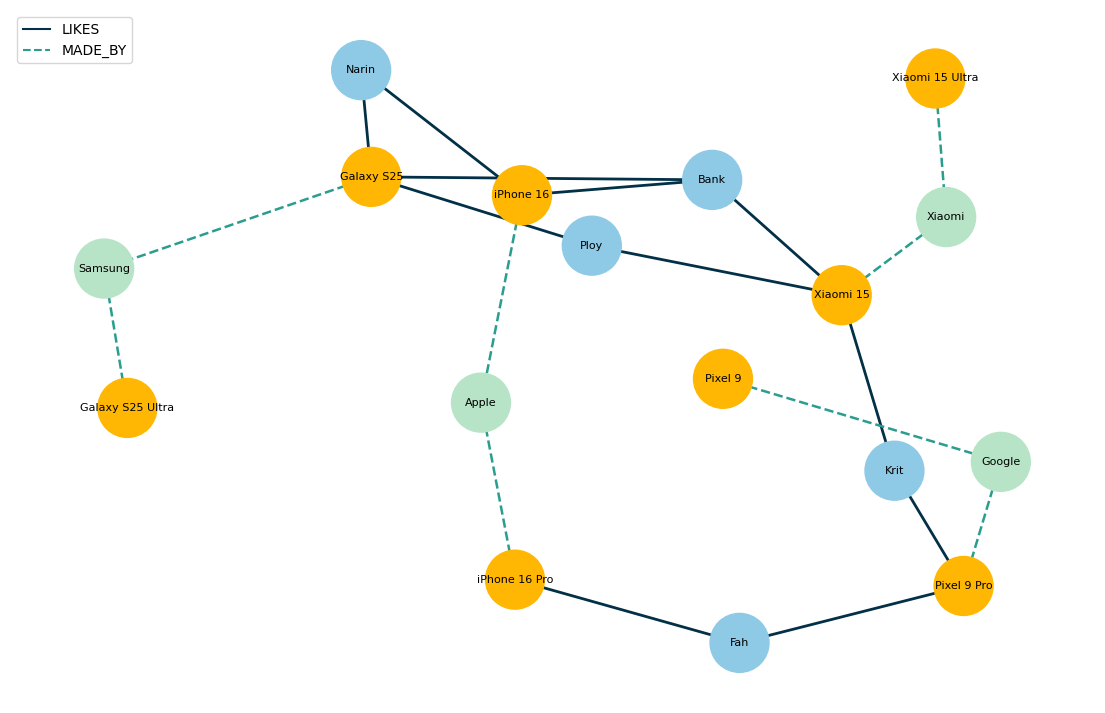

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


def get_edges(query):
    res = driver.execute_query(query, database_=DATABASE)
    return [(r["a"], r["b"]) for r in res.records]


likes_edges = get_edges("MATCH (u:PhoneUser)-[:LIKES]->(p:Smartphone) RETURN u.name AS a, p.name AS b")
brand_edges = get_edges("MATCH (p:Smartphone)-[:MADE_BY]->(b:Brand) RETURN p.name AS a, b.name AS b")

G = nx.Graph()
G.add_nodes_from(users, kind="user")
G.add_nodes_from([p for p, _ in phone_brand], kind="phone")
G.add_nodes_from(sorted({b for _, b in phone_brand}), kind="brand")
G.add_edges_from(likes_edges + brand_edges)

color_map = {"user": "#8ecae6", "phone": "#ffb703", "brand": "#b7e4c7"}
colors = [color_map[G.nodes[n]["kind"]] for n in G.nodes]

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=7, k=0.8)

nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1800)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, edgelist=likes_edges, edge_color="#023047", width=2.0, style="solid")
nx.draw_networkx_edges(G, pos, edgelist=brand_edges, edge_color="#2a9d8f", width=1.8, style="dashed")

plt.legend(handles=[
    mlines.Line2D([], [], color="#023047", linestyle="solid", label="LIKES"),
    mlines.Line2D([], [], color="#2a9d8f", linestyle="dashed", label="MADE_BY"),
], loc="upper left")

plt.axis("off")
plt.show()

ฟ้า = ผู้ใช้ / ส้ม = มือถือ / เขียว = ยี่ห้อ

หรือดูใน Neo4j Aura → Query แล้วรัน

```
MATCH p = (:PhoneUser)-[:LIKES]->(:Smartphone)-[:MADE_BY]->(:Brand)
RETURN p
```

Step 13 — Query 1 hop: Narin ชอบมือถือรุ่นอะไรบ้าง

In [ ]:
result = driver.execute_query(
    """
    MATCH (u:PhoneUser {name: $name})-[:LIKES]->(p:Smartphone)

    RETURN p.name AS phone

    ORDER BY phone
    """,

    name="Narin",
    database_=DATABASE
)

print([record["phone"] for record in result.records])

['Galaxy S25', 'iPhone 16']


Step 14 — Query 2 hop: ใครชอบมือถือเหมือน Narin

`Narin -[:LIKES]-> Phone <-[:LIKES]- คนอื่น`

In [ ]:
result = driver.execute_query(
    """
    MATCH
        (me:PhoneUser {name: $name})
        -[:LIKES]->
        (p:Smartphone)
        <-[:LIKES]-
        (other:PhoneUser)

    WHERE other <> me

    RETURN
        p.name AS phone,
        collect(other.name) AS similar_users

    ORDER BY phone
    """,

    name="Narin",
    database_=DATABASE
)

for record in result.records:
    print(record["phone"], "->", record["similar_users"])

Galaxy S25 -> ['Ploy', 'Bank']
iPhone 16 -> ['Bank']


---
# Mini Project: Recommendation System

Step 15 — แนะนำแบบที่ 1: จากคนที่ชอบเหมือนกัน (เดิน 3 hop)

```
Narin
 ↓  LIKES
มือถือที่ Narin ชอบ
 ↓  <-LIKES
คนอื่นที่ชอบเหมือนกัน
 ↓  LIKES
มือถือรุ่นอื่นที่คนเหล่านั้นชอบ
 ↓
แนะนำให้ Narin
```
- `WHERE NOT EXISTS` = ตัดรุ่นที่ Narin ชอบอยู่แล้วออก
- `count(*)` = จำนวนเส้นทางที่ไปถึงรุ่นนั้น ยิ่งมากยิ่งน่าแนะนำ

In [ ]:
result = driver.execute_query(
    """
    MATCH
        (me:PhoneUser {name: $name})
        -[:LIKES]->
        (:Smartphone)
        <-[:LIKES]-
        (other:PhoneUser)
        -[:LIKES]->
        (rec:Smartphone)

    WHERE other <> me
      AND NOT EXISTS {
          MATCH (me)-[:LIKES]->(rec)
      }

    RETURN
        rec.name AS phone,
        count(*) AS score

    ORDER BY
        score DESC,
        phone
    """,

    name="Narin",
    database_=DATABASE
)

pd.DataFrame(
    [record.data() for record in result.records]
)

,phone,score
0,Xiaomi 15,3


Xiaomi 15 ได้ 3 เพราะเดินไปถึงได้ 3 เส้นทาง

```
Narin → iPhone 16  → Bank → Xiaomi 15
Narin → Galaxy S25 → Bank → Xiaomi 15
Narin → Galaxy S25 → Ploy → Xiaomi 15
```

Step 16 — ทำเป็น Python Function

In [ ]:
def recommend_phones(name, top_n=None):

    query = """
    MATCH
        (me:PhoneUser {name: $name})
        -[:LIKES]->
        (:Smartphone)
        <-[:LIKES]-
        (other:PhoneUser)
        -[:LIKES]->
        (rec:Smartphone)

    WHERE other <> me
      AND NOT EXISTS {
          MATCH (me)-[:LIKES]->(rec)
      }

    RETURN
        rec.name AS phone,
        count(*) AS score

    ORDER BY
        score DESC,
        phone
    """

    if top_n is not None:
        query += "\nLIMIT $top_n"

    result = driver.execute_query(
        query,
        name=name,
        top_n=top_n,
        database_=DATABASE
    )

    return [
        (record["phone"], record["score"])
        for record in result.records
    ]

In [ ]:
recommend_phones("Narin")

[('Xiaomi 15', 3)]

Step 17 — ดูผลของผู้ใช้ทุกคน (เอาแค่ 3 อันดับแรก)

In [ ]:
for user in users:
    print(f"{user:6s} ->", recommend_phones(user, top_n=3))

Narin  -> [('Xiaomi 15', 3)]
Ploy   -> [('iPhone 16', 3), ('Pixel 9 Pro', 1)]
Bank   -> [('Pixel 9 Pro', 1)]
Fah    -> [('Xiaomi 15', 1)]
Krit   -> [('Galaxy S25', 2), ('iPhone 16', 1), ('iPhone 16 Pro', 1)]


สังเกต: **Bank** กับ **Fah** ได้แค่ 1 รุ่น เพราะเชื่อมกับคนอื่นน้อย ส่วนแนะนำด้วยยี่ห้อในขั้นถัดไปช่วยเสริมตรงนี้

Step 18 — แนะนำแบบที่ 2: จากยี่ห้อเดียวกัน (ไม่ต้องพึ่งผู้ใช้คนอื่นเลย)

```
Narin → LIKES → มือถือที่ชอบ → MADE_BY → ยี่ห้อ ← MADE_BY ← รุ่นอื่นของยี่ห้อนั้น
```

In [ ]:
def recommend_by_brand(name):

    result = driver.execute_query(
        """
        MATCH
            (me:PhoneUser {name: $name})
            -[:LIKES]->
            (:Smartphone)
            -[:MADE_BY]->
            (:Brand)
            <-[:MADE_BY]-
            (rec:Smartphone)

        WHERE NOT EXISTS {
            MATCH (me)-[:LIKES]->(rec)
        }

        RETURN
            rec.name AS phone,
            count(*) AS score

        ORDER BY
            score DESC,
            phone
        """,

        name=name,
        database_=DATABASE
    )

    return [
        (record["phone"], record["score"])
        for record in result.records
    ]


print("Narin ->", recommend_by_brand("Narin"))
print("Fah   ->", recommend_by_brand("Fah"))

Narin -> [('Galaxy S25 Ultra', 1), ('iPhone 16 Pro', 1)]
Fah   -> [('Pixel 9', 1), ('iPhone 16', 1)]


Narin ได้ iPhone 16 Pro, Galaxy S25 Ultra (ยี่ห้อ Apple / Samsung ที่เขาชอบอยู่)

Fah ได้ iPhone 16 (ยี่ห้อ Apple) และ Pixel 9 (ยี่ห้อ Google) โดยไม่ต้องพึ่งผู้ใช้คนอื่นเลย

Step 19 — ปิด Connection เมื่อเสร็จ

In [ ]:
driver.close()

print("Neo4j connection closed")

Neo4j connection closed
